In [ ]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# --- PRE-REQUISITE (Ensuring data is ready) ---
# We use the column names we found earlier: 'Comment_Text' and 'Toxicity_Label'
df = pd.read_csv('toxic_comments_dataset.csv')
df = df.dropna().drop_duplicates()

# --- TASK 3: NLP TOKENIZATION AND SEQUENCE PADDING ---

# 1. Separate the text and the labels
X = df['Comment_Text'].astype(str)
y = df['Toxicity_Label']

# 2. Encode Labels (Turning 'Toxic', 'Clean' etc. into numbers like 0, 1, 2)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_classes = len(label_encoder.classes_)

# 3. Split the data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# 4. Create the Tokenizer (Using only training text)
max_words = 10000  # Number of unique words to keep
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

# 5. Convert text comments into numerical sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# 6. Apply Padding (Ensuring all sequences are the same length)
max_len = 100 # Maximum length of a comment
X_train_padded = pad_sequences(X_train_sequences, maxlen=max_len, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=max_len, padding='post', truncating='post')

# --- DISPLAY RESULTS FOR SCREENSHOT ---
print("--- Task 3 Results ---")
print(f"Total Classes found: {label_encoder.classes_}")
print(f"Sample Text: {X_train.iloc[0][:50]}...")
print(f"Sample Sequence: {X_train_sequences[0][:10]}...")
print(f"Padded Training Shape: {X_train_padded.shape}")
print(f"Padded Testing Shape: {X_test_padded.shape}")

--- Task 3 Results ---
Total Classes found: ['Clean' 'Identity_Attack' 'Severe_Toxic' 'Threat' 'Toxic']
Sample Text: This article provides useful information and clear...
Sample Sequence: [3, 11, 12, 13, 14, 2, 15, 16]...
Padded Training Shape: (24000, 100)
Padded Testing Shape: (6000, 100)


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, SpatialDropout1D

# 1. Build the Deep Learning Model (Architecture)
model = Sequential([
    # Layer 1: Embedding (Turns word numbers into meaningful vectors)
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    # Layer 2: SpatialDropout (Prevents the model from relying too much on specific words)
    SpatialDropout1D(0.3),

    # Layer 3: LSTM (The "memory" that understands context)
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    # Layer 4: Dense (Hidden Layer with ReLU activation)
    Dense(32, activation='relu'),

    # Layer 5: Dropout (Prevents overfitting)
    Dropout(0.3),

    # Layer 6: Softmax (The final decision layer for multi-class classification)
    Dense(num_classes, activation='softmax')
])

# 2. Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 3. Train the Model
print("--- Model Training Started ---")
# We use 15 epochs (between the required 10-20) and a validation split of 20%
history = model.fit(X_train_padded, y_train,
                    epochs=15,
                    batch_size=32,
                    validation_split=0.2,
                    verbose=1)

print("\n--- Training Finished ---")

--- Model Training Started ---
Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


600/600 ━━━━━━━━━━━━━━━━━━━━ 91s 145ms/step - accuracy: 0.6135 - loss: 1.1305 - val_accuracy: 0.6119 - val_loss: 1.1159
Epoch 2/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 143ms/step - accuracy: 0.6173 - loss: 1.1127 - val_accuracy: 0.6119 - val_loss: 1.1155
Epoch 3/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 87s 144ms/step - accuracy: 0.6173 - loss: 1.1106 - val_accuracy: 0.6119 - val_loss: 1.1173
Epoch 4/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 90s 151ms/step - accuracy: 0.6173 - loss: 1.1084 - val_accuracy: 0.6119 - val_loss: 1.1148
Epoch 5/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 144s 155ms/step - accuracy: 0.6173 - loss: 1.1059 - val_accuracy: 0.6119 - val_loss: 1.1151
Epoch 6/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 141s 153ms/step - accuracy: 0.6173 - loss: 1.1065 - val_accuracy: 0.6119 - val_loss: 1.1180
Epoch 7/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 93s 155ms/step - accuracy: 0.6173 - loss: 1.1041 - val_accuracy: 0.6119 - val_loss: 1.1150
Epoch 8/15
600/600 ━━━━━━━━━━━━━━━━━━━━ 90s 150ms/step - accuracy: 0.6173 - loss: 1.1031 - 

--- Test Results ---
Test Loss: 1.0730
Test Accuracy: 0.6315
188/188 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step

--- Classification Report ---
                 precision    recall  f1-score   support

          Clean       0.63      1.00      0.77      3789
Identity_Attack       0.00      0.00      0.00       292
   Severe_Toxic       0.00      0.00      0.00       349
         Threat       0.00      0.00      0.00       266
          Toxic       0.00      0.00      0.00      1304

       accuracy                           0.63      6000
      macro avg       0.13      0.20      0.15      6000
   weighted avg       0.40      0.63      0.49      6000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


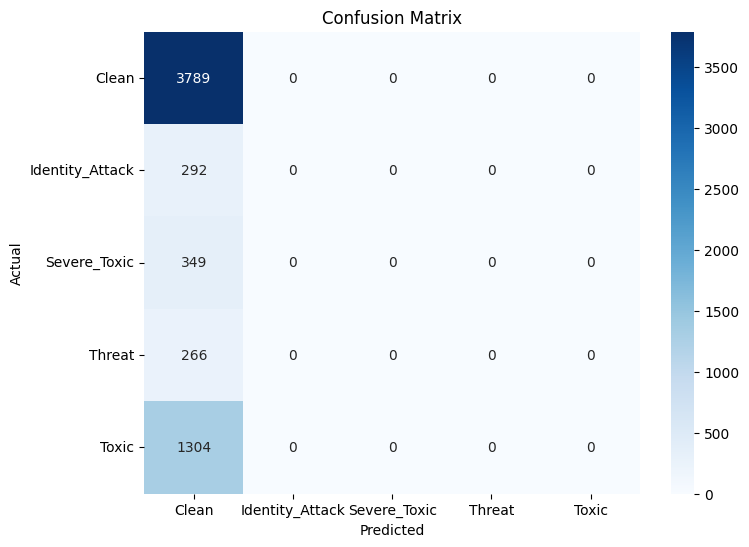

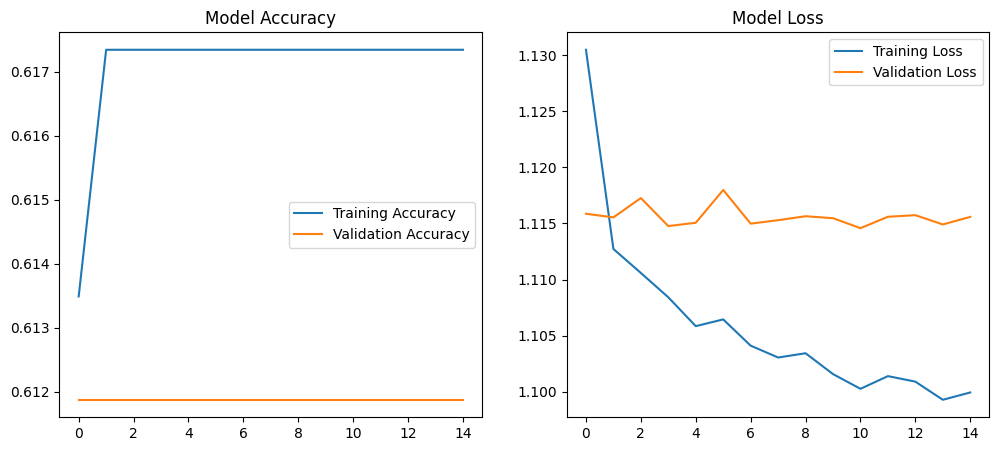


Testing new comment: 'I really love how you explained this, thank you!'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Prediction: Clean


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Evaluate the model on the Test Dataset
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"--- Test Results ---")
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# 2. Get Predictions for the Confusion Matrix
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Display Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# 4. Create and Display Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 5. Plot Accuracy and Loss Curves
plt.figure(figsize=(12, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

# 6. Test on a New Comment
def predict_toxicity(text):
    # Clean and Tokenize the new comment
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=max_len, padding='post')
    # Predict
    prediction = model.predict(padded)
    result = label_encoder.inverse_transform([np.argmax(prediction)])
    return result[0]

# Try a custom test
new_comment = "I really love how you explained this, thank you!"
print(f"\nTesting new comment: '{new_comment}'")
print(f"Prediction: {predict_toxicity(new_comment)}")